Crop Yield Prediction and Agricultural Analytics System

In [178]:
import pandas as pd

In [179]:
yield_df = pd.read_csv('yield.csv')
pesticide_df = pd.read_csv('pesticides.csv')
rainfall_df = pd.read_csv('rainfall.csv')
temperature_df = pd.read_csv('temp.csv')

Yield data info

In [180]:
yield_df.head()


,Domain Code,Domain,Area Code,Area,Element Code,Element,Item Code,Item,Year Code,Year,Unit,Value
0,QC,Crops,2,Afghanistan,5419,Yield,56,Maize,1961,1961,hg/ha,14000
1,QC,Crops,2,Afghanistan,5419,Yield,56,Maize,1962,1962,hg/ha,14000
2,QC,Crops,2,Afghanistan,5419,Yield,56,Maize,1963,1963,hg/ha,14260
3,QC,Crops,2,Afghanistan,5419,Yield,56,Maize,1964,1964,hg/ha,14257
4,QC,Crops,2,Afghanistan,5419,Yield,56,Maize,1965,1965,hg/ha,14400


In [181]:
yield_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56717 entries, 0 to 56716
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Domain Code   56717 non-null  object
 1   Domain        56717 non-null  object
 2   Area Code     56717 non-null  int64 
 3   Area          56717 non-null  object
 4   Element Code  56717 non-null  int64 
 5   Element       56717 non-null  object
 6   Item Code     56717 non-null  int64 
 7   Item          56717 non-null  object
 8   Year Code     56717 non-null  int64 
 9   Year          56717 non-null  int64 
 10  Unit          56717 non-null  object
 11  Value         56717 non-null  int64 
dtypes: int64(6), object(6)
memory usage: 5.2+ MB


In [182]:
yield_df.describe()

,Area Code,Element Code,Item Code,Year Code,Year,Value
count,56717.000000,56717.0,56717.000000,56717.000000,56717.000000,56717.000000
mean,125.650422,5419.0,111.611651,1989.669570,1989.669570,62094.660084
std,75.120195,0.0,101.278435,16.133198,16.133198,67835.932856
min,1.000000,5419.0,15.000000,1961.000000,1961.000000,0.000000
25%,58.000000,5419.0,56.000000,1976.000000,1976.000000,15680.000000
50%,122.000000,5419.0,116.000000,1991.000000,1991.000000,36744.000000
75%,184.000000,5419.0,125.000000,2004.000000,2004.000000,86213.000000
max,351.000000,5419.0,489.000000,2016.000000,2016.000000,1000000.000000


Standardizing Yield data columns


In [183]:
yield_df= yield_df.rename(columns={'Area': 'Country', 'Item': 'Crop', 'Year': 'Year', 'Value': 'Yield'})

In [184]:
yield_df.isna().sum()

Domain Code     0
Domain          0
Area Code       0
Country         0
Element Code    0
Element         0
Item Code       0
Crop            0
Year Code       0
Year            0
Unit            0
Yield           0
dtype: int64

In [185]:
yield_df=yield_df[['Country', 'Year', 'Crop', 'Yield']]

Pesticide Data Information

In [186]:
pesticide_df.head()

,Domain,Area,Element,Item,Year,Unit,Value
0,Pesticides Use,Albania,Use,Pesticides (total),1990,tonnes of active ingredients,121.0
1,Pesticides Use,Albania,Use,Pesticides (total),1991,tonnes of active ingredients,121.0
2,Pesticides Use,Albania,Use,Pesticides (total),1992,tonnes of active ingredients,121.0
3,Pesticides Use,Albania,Use,Pesticides (total),1993,tonnes of active ingredients,121.0
4,Pesticides Use,Albania,Use,Pesticides (total),1994,tonnes of active ingredients,201.0


In [187]:
pesticide_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4349 entries, 0 to 4348
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Domain   4349 non-null   object 
 1   Area     4349 non-null   object 
 2   Element  4349 non-null   object 
 3   Item     4349 non-null   object 
 4   Year     4349 non-null   int64  
 5   Unit     4349 non-null   object 
 6   Value    4349 non-null   float64
dtypes: float64(1), int64(1), object(5)
memory usage: 238.0+ KB


In [188]:
pesticide_df.isna().sum()

Domain     0
Area       0
Element    0
Item       0
Year       0
Unit       0
Value      0
dtype: int64

Standardizing Pesticide data columns

In [189]:
pesticide_df= pesticide_df.rename(columns={'Area': 'Country', 'Item': 'Pesticide', 'Year': 'Year', 'Value': 'Pesticide_Usage'})

In [190]:
pesticide_df=pesticide_df.groupby(['Country', 'Year'], as_index=False)['Pesticide_Usage'].sum()
pesticide_df.head()

,Country,Year,Pesticide_Usage
0,Albania,1990,121.0
1,Albania,1991,121.0
2,Albania,1992,121.0
3,Albania,1993,121.0
4,Albania,1994,201.0


Temperature Data Information

In [191]:
temperature_df.head()

,year,country,avg_temp
0,1849,Côte D'Ivoire,25.58
1,1850,Côte D'Ivoire,25.52
2,1851,Côte D'Ivoire,25.67
3,1852,Côte D'Ivoire,NaN
4,1853,Côte D'Ivoire,NaN


In [192]:
temperature_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71311 entries, 0 to 71310
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   year      71311 non-null  int64  
 1   country   71311 non-null  object 
 2   avg_temp  68764 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 1.6+ MB


Cleaning Temperature data

In [193]:
temperature_df.isna().mean()*100

year        0.000000
country     0.000000
avg_temp    3.571679
dtype: float64

In [194]:
temperature_df['avg_temp'] = temperature_df['avg_temp'].interpolate(method='linear')
temperature_df.isna().sum()

year        0
country     0
avg_temp    0
dtype: int64

In [195]:
temperature_df.columns

Index(['year', 'country', 'avg_temp'], dtype='object')

In [196]:
temperature_df= temperature_df.rename(columns={'country': 'Country', 'year': 'Year', 'avg_temp': 'Avg_temperature'})

In [197]:
temperature_df=temperature_df.groupby(['Country', 'Year'], as_index=False)['Avg_temperature'].mean()
temperature_df.head()

,Country,Year,Avg_temperature
0,Afghanistan,1833,13.91
1,Afghanistan,1834,13.91
2,Afghanistan,1835,14.71
3,Afghanistan,1836,15.09
4,Afghanistan,1837,15.47


Rainfall Data Information

In [198]:
rainfall_df.head()

,Area,Year,average_rain_fall_mm_per_year
0,Afghanistan,1985,327
1,Afghanistan,1986,327
2,Afghanistan,1987,327
3,Afghanistan,1989,327
4,Afghanistan,1990,327


In [199]:
rainfall_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6727 entries, 0 to 6726
Data columns (total 3 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0    Area                          6727 non-null   object
 1   Year                           6727 non-null   int64 
 2   average_rain_fall_mm_per_year  5953 non-null   object
dtypes: int64(1), object(2)
memory usage: 157.8+ KB


In [200]:
rainfall_df['average_rain_fall_mm_per_year']=pd.to_numeric(rainfall_df['average_rain_fall_mm_per_year'], errors='coerce')

Cleaning Rainfall Data

In [201]:
rainfall_df['average_rain_fall_mm_per_year']= rainfall_df['average_rain_fall_mm_per_year'].astype(float)
rainfall_df.isna().mean()*100

 Area                             0.000000
Year                              0.000000
average_rain_fall_mm_per_year    11.595065
dtype: float64

In [202]:
rainfall_df['average_rain_fall_mm_per_year']=rainfall_df['average_rain_fall_mm_per_year'].interpolate(method='linear')
rainfall_df.isna().sum()

 Area                            0
Year                             0
average_rain_fall_mm_per_year    0
dtype: int64

In [203]:
rainfall_df.columns

Index([' Area', 'Year', 'average_rain_fall_mm_per_year'], dtype='object')

In [204]:
rainfall_df=rainfall_df.rename(columns={' Area': 'Country', 'Year': 'Year', 'average_rain_fall_mm_per_year': 'Average_rainfall_mm_per_year'})

In [205]:
rainfall_df = rainfall_df.groupby(['Country', 'Year'], as_index=False)['Average_rainfall_mm_per_year'].mean()
rainfall_df.head()

,Country,Year,Average_rainfall_mm_per_year
0,Afghanistan,1985,327.0
1,Afghanistan,1986,327.0
2,Afghanistan,1987,327.0
3,Afghanistan,1989,327.0
4,Afghanistan,1990,327.0


Merging the four Datasets

In [206]:
print(f'yield shape: {yield_df.shape}')
print(f'pesticide shape: {pesticide_df.shape}')
print(f'temperature shape: {temperature_df.shape}')
print(f'rainfall shape: {rainfall_df.shape}')

yield shape: (56717, 4)
pesticide shape: (4349, 3)
temperature shape: (28514, 3)
rainfall shape: (6727, 3)


In [207]:
print(f'yield columns: {yield_df.columns}')
print(f'pesticide columns: {pesticide_df.columns}')         
print(f'rainfall columns: {rainfall_df.columns}')
print(f'temperature columns: {temperature_df.columns}') 

yield columns: Index(['Country', 'Year', 'Crop', 'Yield'], dtype='object')
pesticide columns: Index(['Country', 'Year', 'Pesticide_Usage'], dtype='object')
rainfall columns: Index(['Country', 'Year', 'Average_rainfall_mm_per_year'], dtype='object')
temperature columns: Index(['Country', 'Year', 'Avg_temperature'], dtype='object')


In [208]:
df= yield_df.merge(pesticide_df, on=['Country', 'Year'], how='inner').merge(temperature_df, on=['Country', 'Year'], how='inner').merge(rainfall_df, on=['Country', 'Year'], how='inner')
df.head()

,Country,Year,Crop,Yield,Pesticide_Usage,Avg_temperature,Average_rainfall_mm_per_year
0,Albania,1990,Maize,36613,121.0,16.37,1485.0
1,Albania,1991,Maize,29068,121.0,15.36,1485.0
2,Albania,1992,Maize,24876,121.0,16.06,1485.0
3,Albania,1993,Maize,24185,121.0,16.05,1485.0
4,Albania,1994,Maize,25848,201.0,16.96,1485.0


In [209]:
df.isna().mean()*100

Country                         0.0
Year                            0.0
Crop                            0.0
Yield                           0.0
Pesticide_Usage                 0.0
Avg_temperature                 0.0
Average_rainfall_mm_per_year    0.0
dtype: float64

In [210]:
df.shape

(13136, 7)

In [211]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13136 entries, 0 to 13135
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Country                       13136 non-null  object 
 1   Year                          13136 non-null  int64  
 2   Crop                          13136 non-null  object 
 3   Yield                         13136 non-null  int64  
 4   Pesticide_Usage               13136 non-null  float64
 5   Avg_temperature               13136 non-null  float64
 6   Average_rainfall_mm_per_year  13136 non-null  float64
dtypes: float64(3), int64(2), object(2)
memory usage: 718.5+ KB


Feature Engineering

In [212]:
df=df.sort_values(by=['Country','Crop','Year']).reset_index(drop=True)
df['climate_factor'] = df['Avg_temperature'] * df['Average_rainfall_mm_per_year']
df['yield_lag'] = df.groupby('Country')['Yield'].shift(1)
df['rolling_avg_yield'] = df.groupby('Country')['Yield'].transform(lambda x: x.rolling(window=5, min_periods=1).mean().shift(1))
df.head()

,Country,Year,Crop,Yield,Pesticide_Usage,Avg_temperature,Average_rainfall_mm_per_year,climate_factor,yield_lag,rolling_avg_yield
0,Albania,1990,Maize,36613,121.0,16.37,1485.0,24309.45,NaN,NaN
1,Albania,1991,Maize,29068,121.0,15.36,1485.0,22809.60,36613.0,36613.000000
2,Albania,1992,Maize,24876,121.0,16.06,1485.0,23849.10,29068.0,32840.500000
3,Albania,1993,Maize,24185,121.0,16.05,1485.0,23834.25,24876.0,30185.666667
4,Albania,1994,Maize,25848,201.0,16.96,1485.0,25185.60,24185.0,28685.500000


Final cleaning of the merge dataset

In [213]:
df.isna().sum()

Country                           0
Year                              0
Crop                              0
Yield                             0
Pesticide_Usage                   0
Avg_temperature                   0
Average_rainfall_mm_per_year      0
climate_factor                    0
yield_lag                       101
rolling_avg_yield               101
dtype: int64

In [214]:
df=df.dropna()
df.isna().sum()

Country                         0
Year                            0
Crop                            0
Yield                           0
Pesticide_Usage                 0
Avg_temperature                 0
Average_rainfall_mm_per_year    0
climate_factor                  0
yield_lag                       0
rolling_avg_yield               0
dtype: int64

In [215]:
df['Year'].unique()

array([1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001,
       2002, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013,
       1990])

In [216]:
df.head()

,Country,Year,Crop,Yield,Pesticide_Usage,Avg_temperature,Average_rainfall_mm_per_year,climate_factor,yield_lag,rolling_avg_yield
1,Albania,1991,Maize,29068,121.0,15.36,1485.0,22809.60,36613.0,36613.000000
2,Albania,1992,Maize,24876,121.0,16.06,1485.0,23849.10,29068.0,32840.500000
3,Albania,1993,Maize,24185,121.0,16.05,1485.0,23834.25,24876.0,30185.666667
4,Albania,1994,Maize,25848,201.0,16.96,1485.0,25185.60,24185.0,28685.500000
5,Albania,1995,Maize,31300,251.0,15.67,1485.0,23269.95,25848.0,28118.000000


Preprocessing


In [217]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split


Data Splitting For ML

In [218]:
train =df[df['Year']<=2008]
test =df[df['Year']>2008]

X_train = train.drop(columns=['Yield'])
y_train =train['Yield']

X_test =test.drop(columns=['Yield'])
y_test =test['Yield']

Label coding and Scaling

In [219]:
num=df[['Year', 'Avg_temperature', 'Average_rainfall_mm_per_year', 'Pesticide_Usage', 'climate_factor', 'yield_lag', 'rolling_avg_yield']]
cat=df[['Country','Crop']]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num.columns),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat.columns)
    ]
)



In [220]:
preprocessor.fit(X_train)
X_train_preprocessed = preprocessor.transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)


Base Model (Linear Regression)

In [221]:
model=LinearRegression()
model.fit(X_train_preprocessed, y_train)
y_pred= model.predict(X_test_preprocessed)

In [222]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)
print(f'Mean Squared Error: {mse}')
print(f'R^2 Score: {r2}')           
print(f'Mean Absolute Error: {mae}')
print(f'Mean Absolute Percentage Error: {mape}')

Mean Squared Error: 471739385.8704862
R^2 Score: 0.9381753101684294
Mean Absolute Error: 13960.389323268604
Mean Absolute Percentage Error: 0.37901766247476104


model 2 - Random Forest

In [223]:
model2 = RandomForestRegressor()
model2.fit(X_train_preprocessed, y_train)
y_pred2= model2.predict(X_test_preprocessed)

In [224]:
mse = mean_squared_error(y_test, y_pred2)
r2 = r2_score(y_test, y_pred2)
mae = mean_absolute_error(y_test, y_pred2)
mape = mean_absolute_percentage_error(y_test, y_pred2)
print(f'Mean Squared Error: {mse}')
print(f'R^2 Score: {r2}')           
print(f'Mean Absolute Error: {mae}')
print(f'Mean Absolute Percentage Error: {mape}')

Mean Squared Error: 391085830.90965056
R^2 Score: 0.9487455130571832
Mean Absolute Error: 8956.846153321976
Mean Absolute Percentage Error: 0.15988300806030648


In [225]:
importances = model2.feature_importances_
feature_names = preprocessor.get_feature_names_out()
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
feature_importance_df['Feature'] = feature_importance_df['Feature'].str.replace('num__', '', regex=False)
feature_importance_df['Feature'] = feature_importance_df['Feature'].str.replace('cat__', '', regex=False)
feature_importance_df.head(10)

,Feature,Importance
5,yield_lag,0.870860
0,Year,0.070094
6,rolling_avg_yield,0.008409
110,Crop_Potatoes,0.006069
3,Pesticide_Usage,0.005411
1,Avg_temperature,0.005271
4,climate_factor,0.003911
115,Crop_Wheat,0.003691
2,Average_rainfall_mm_per_year,0.002041
114,Crop_Sweet potatoes,0.001726


In [226]:
df_results = X_test.copy().reset_index(drop=True)
df_results['Actual_Yield'] = y_test.reset_index(drop=True)
df_results['Predicted_Yield'] = y_pred2
df_results['Error(%)'] = (df_results['Actual_Yield'] - df_results['Predicted_Yield']) / df_results['Actual_Yield'] * 100
print(df_results.head())
df_results.to_csv('yield_predictions.csv', index=False)

   Country  Year   Crop  Pesticide_Usage  Avg_temperature  \
0  Albania  2009  Maize          1132.50            16.73   
1  Albania  2010  Maize          1311.17            16.52   
2  Albania  2011  Maize          1302.63            16.45   
3  Albania  2012  Maize           766.25            16.70   
4  Albania  2013  Maize           982.32            17.41   

   Average_rainfall_mm_per_year  climate_factor  yield_lag  rolling_avg_yield  \
0                        1485.0        24844.05    50000.0            47696.4   
1                        1485.0        24532.20    55693.0            49595.6   
2                        1485.0        24428.25    66790.0            53865.2   
3                        1485.0        24799.50    59869.0            55816.8   
4                        1485.0        25853.85    67290.0            59928.4   

   Actual_Yield  Predicted_Yield   Error(%)  
0         55693         54454.77   2.223314  
1         66790         56842.54  14.893637  
2       

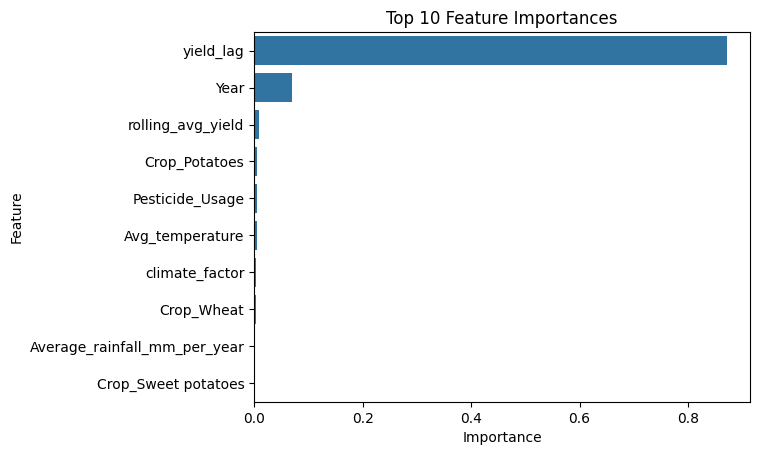

In [227]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10))
plt.title('Top 10 Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

In [228]:
train_nl =df[df['Year']<=2008]
test_nl =df[df['Year']>2008]

X_train_nl = train_nl.drop(columns=['Yield', 'yield_lag', 'rolling_avg_yield'])
y_train_nl =train_nl['Yield']

X_test_nl =test_nl.drop(columns=['Yield', 'yield_lag', 'rolling_avg_yield'])
y_test_nl =test_nl['Yield']

Model without Rolling averages and lag_yields

In [229]:
num_no_lag=df[['Year', 'Avg_temperature', 'Average_rainfall_mm_per_year', 'Pesticide_Usage', 'climate_factor']]
cat=df[['Country','Crop']]
preprocessor_no_lag = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_no_lag.columns),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat.columns)
    ]
)

In [230]:
preprocessor_no_lag.fit(X_train_nl)
X_train_preprocessed_nl = preprocessor_no_lag.transform(X_train_nl)
X_test_preprocessed_nl = preprocessor_no_lag.transform(X_test_nl)
model_no_lag = RandomForestRegressor()
model_no_lag.fit(X_train_preprocessed_nl, y_train_nl)
y_pred_no_lag= model_no_lag.predict(X_test_preprocessed_nl)

In [231]:
mse = mean_squared_error(y_test_nl, y_pred_no_lag)
r2 = r2_score(y_test_nl, y_pred_no_lag)
mae = mean_absolute_error(y_test_nl, y_pred_no_lag)
mape = mean_absolute_percentage_error(y_test_nl, y_pred_no_lag)
print(f'Mean Squared Error: {mse}')
print(f'R^2 Score: {r2}')           
print(f'Mean Absolute Error: {mae}')
print(f'Mean Absolute Percentage Error: {mape}')

Mean Squared Error: 531340664.9877602
R^2 Score: 0.930364152768055
Mean Absolute Error: 11803.69395229983
Mean Absolute Percentage Error: 0.21777313098534987


In [232]:
df_results_no_lag = X_test_nl.copy().reset_index(drop=True)
df_results_no_lag['Actual_Yield'] = y_test_nl.reset_index(drop=True)
df_results_no_lag['Predicted_Yield'] = y_pred_no_lag
df_results_no_lag['Error(%)'] = (df_results_no_lag['Actual_Yield'] - df_results_no_lag['Predicted_Yield']) / df_results_no_lag['Actual_Yield'] * 100
print(df_results_no_lag.head())
df_results_no_lag.to_csv('yield_predictions_no_lag.csv', index=False)

   Country  Year   Crop  Pesticide_Usage  Avg_temperature  \
0  Albania  2009  Maize          1132.50            16.73   
1  Albania  2010  Maize          1311.17            16.52   
2  Albania  2011  Maize          1302.63            16.45   
3  Albania  2012  Maize           766.25            16.70   
4  Albania  2013  Maize           982.32            17.41   

   Average_rainfall_mm_per_year  climate_factor  Actual_Yield  \
0                        1485.0        24844.05         55693   
1                        1485.0        24532.20         66790   
2                        1485.0        24428.25         59869   
3                        1485.0        24799.50         67290   
4                        1485.0        25853.85         69533   

   Predicted_Yield   Error(%)  
0         47307.06  15.057440  
1         46184.62  30.850996  
2         46312.28  22.643973  
3         45813.57  31.916228  
4         47158.55  32.178174  


In [233]:
importance_nl = model_no_lag.feature_importances_
feature_names_nl = preprocessor_no_lag.get_feature_names_out()
feature_importance_df = pd.DataFrame({'Feature_nl': feature_names_nl, 'Importance_nl': importance_nl})
feature_importance_df = feature_importance_df.sort_values(by='Importance_nl', ascending=False)
feature_importance_df['Feature_nl'] = feature_importance_df['Feature_nl'].str.replace('num__', '', regex=False)
feature_importance_df['Feature_nl'] = feature_importance_df['Feature_nl'].str.replace('cat__', '', regex=False)
feature_importance_df.head(10)

,Feature_nl,Importance_nl
108,Crop_Potatoes,0.377191
3,Pesticide_Usage,0.111385
2,Average_rainfall_mm_per_year,0.075153
1,Avg_temperature,0.073276
112,Crop_Sweet potatoes,0.044651
4,climate_factor,0.044067
105,Crop_Cassava,0.042752
107,Crop_Plantains and others,0.035291
114,Crop_Yams,0.029463
0,Year,0.024673


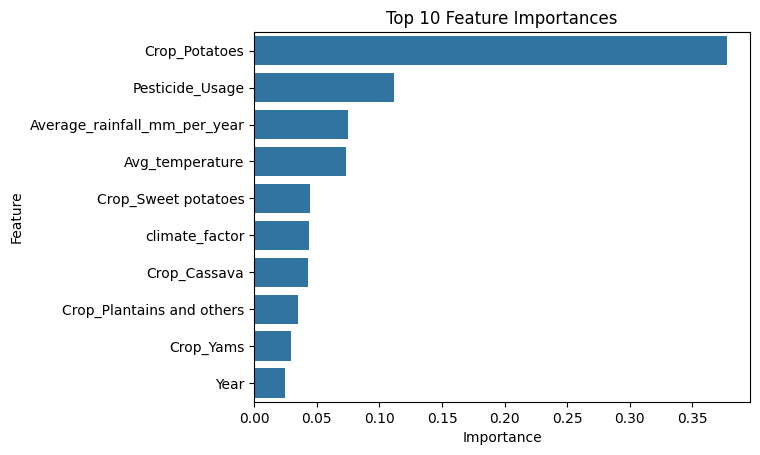

In [234]:
sns.barplot(x='Importance_nl', y='Feature_nl', data=feature_importance_df.head(10))
plt.title('Top 10 Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

tableau dataset

In [235]:
df.to_csv('yield_final_dataset.csv', index=False)

In [236]:
df_15_countries = df[df['Country'].isin(['Niger','Ethiopia','Ghana','Sudan', 'Sri Lanka','India', 'Russia', 'China', 'Israel', 'Brazil', 'United States', 'Australia', 'France', 'Germany', 'Mexico'])]
df_15_countries.head()

,Country,Year,Crop,Yield,Pesticide_Usage,Avg_temperature,Average_rainfall_mm_per_year,climate_factor,yield_lag,rolling_avg_yield
625,Australia,1991,Maize,39938,17866.0,16.606667,534.0,8867.96,41821.0,41821.000000
626,Australia,1992,Maize,51721,22234.0,15.905000,534.0,8493.27,39938.0,40879.500000
627,Australia,1993,Maize,44261,23899.0,16.333333,534.0,8722.00,51721.0,44493.333333
628,Australia,1994,Maize,46620,21057.0,16.278333,534.0,8692.63,44261.0,44435.250000
629,Australia,1995,Maize,48263,25598.0,16.103333,534.0,8599.18,46620.0,44872.200000


In [237]:
df_15_countries['Country'].unique()

array(['Australia', 'Brazil', 'France', 'Germany', 'Ghana', 'India',
       'Mexico', 'Niger', 'Sri Lanka', 'Sudan'], dtype=object)

In [238]:
df_15_countries.to_csv('yield_final_dataset_15_countries.csv', index=False)

https://public.tableau.com/app/profile/abdallah.suallah/viz/project_17794707558410/Climate-YieldDashboard